In [3]:
df = pd.read_csv("student_performance.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())
df.head()

['studentid', 'g1', 'g2', 'g3', 'mjob', 'fjob', 'age', 'address', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


,studentid,g1,g2,g3,mjob,fjob,age,address,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,1,6,2,2,teacher,at_home,21,rural,3,1,no,yes,yes,yes,yes,yes,no,yes
1,2,19,11,18,health,teacher,18,rural,1,1,no,no,no,no,yes,no,no,no
2,3,14,7,19,health,other,20,urban,1,1,yes,yes,yes,no,no,no,yes,yes
3,4,10,2,6,services,health,21,urban,3,1,yes,no,yes,no,yes,no,no,no
4,5,7,0,19,health,health,18,rural,4,1,no,no,yes,no,yes,yes,yes,no


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


Environment ready!
NumPy: 1.26.4
pandas: 2.2.2
scikit-learn: 1.5.1


   StudentID  G1  G2  G3      Mjob     Fjob  age address  studytime  failures  \
0          1   6   2   2   teacher  at_home   21   rural          3         1   
1          2  19  11  18    health  teacher   18   rural          1         1   
2          3  14   7  19    health    other   20   urban          1         1   
3          4  10   2   6  services   health   21   urban          3         1   
4          5   7   0  19    health   health   18   rural          4         1   

  schoolsup famsup paid activities nursery higher internet romantic  
0        no    yes  yes        yes     yes    yes       no      yes  
1        no     no   no         no     yes     no       no       no  
2       yes    yes  yes         no      no     no      yes      yes  
3       yes     no  yes         no     yes     no       no       no  
4        no     no  yes         no     yes    yes      yes       no  
Shape: (100, 18)
   G1  G2  G3  result
0   6   2   2       0
1  19  11  18       1
2  14   7 

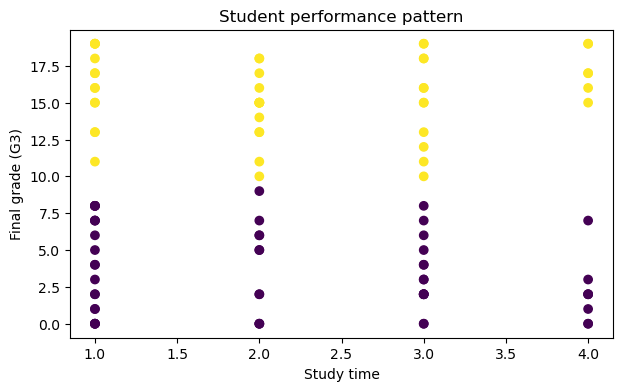

X shape: (100, 4)
y shape: (100,)
Training rows: 80
Testing rows : 20
Model trained!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# Load the CSV file
df = pd.read_csv("student_performance.csv")

print(df.head())
print("Shape:", df.shape)


# Create result column
# G3 >= 10 = Pass
# G3 < 10  = Fail
df["result"] = (df["G3"] >= 10).astype(int)

print(df[["G1", "G2", "G3", "result"]].head())


# -----------------------------------
# Student performance visualization
# -----------------------------------

plt.figure(figsize=(7, 4))

plt.scatter(
    df["studytime"],
    df["G3"],
    c=df["result"]
)

plt.xlabel("Study time")
plt.ylabel("Final grade (G3)")
plt.title("Student performance pattern")

plt.show()


# -----------------------------------
# Select features and target
# -----------------------------------

X = df[["studytime", "failures", "G1", "G2"]]

y = df["result"]


print("X shape:", X.shape)
print("y shape:", y.shape)


# -----------------------------------
# Train-test split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


# -----------------------------------
# Train Decision Tree
# -----------------------------------

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained!")

In [5]:
prediction = model.predict(X_test)

In [6]:
print(prediction)

[1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1]


In [7]:
print(X_test)


    studytime  failures  G1  G2
36          1         1  17   5
18          3         1  11  12
71          2         2  12  16
60          4         0   3  16
11          1         3   2   4
26          3         1  19  12
39          1         0  19  19
43          1         3   7   0
33          1         3  17   1
41          1         2   6   6
78          4         1   0   1
2           1         1  14   7
98          4         1  15   3
95          3         0  11  15
16          1         2   0  14
31          2         3   8   6
17          2         3  11   9
53          3         1   5   0
73          3         0  14   1
77          2         0   8  18


In [10]:
accuracy= accuracy_score(y_test, prediction)
print(f"test accuracy : {accuracy:.2%}")

test accuracy : 60.00%


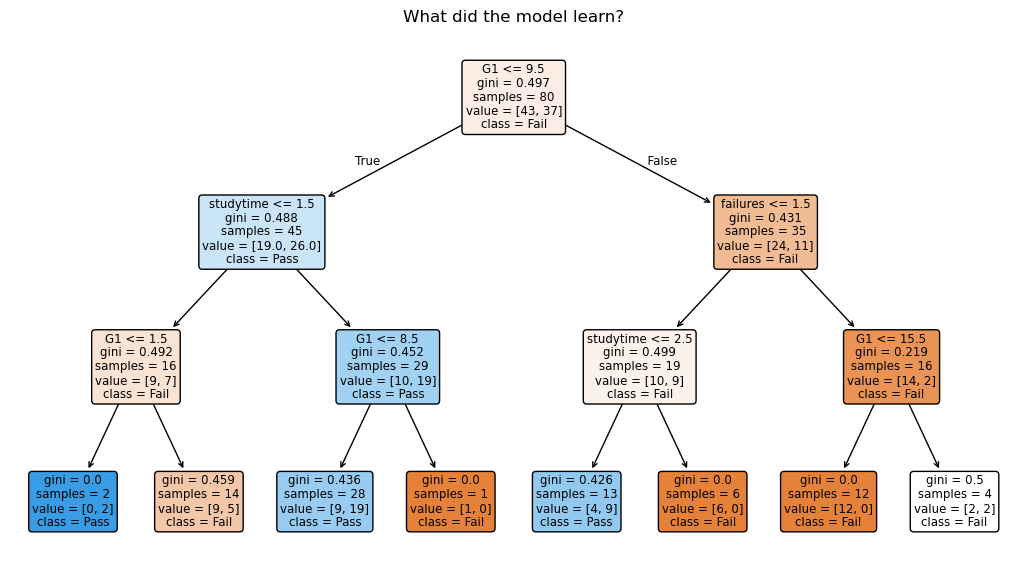

In [11]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()